In [ ]:
import torch
print("GPU disponible:", torch.cuda.is_available())
print("Dispositivo:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU ⚠️ ve a Entorno → T4 GPU")

GPU disponible: False
Dispositivo: CPU ⚠️ ve a Entorno → T4 GPU


In [ ]:
!pip install kagglehub --quiet
print("✅ kagglehub instalado")

✅ kagglehub instalado


In [ ]:
import kagglehub

print("⬇️ Descargando Dataset Time Of Day Dataset...")
path_landscape_pic = kagglehub.dataset_download("aymenkhouja/timeofdaydataset")
print(f"   ✅ {path_landscape_pic}")

print("⬇️ Descargando Dataset Multi-class Weather...")
path_weather = kagglehub.dataset_download("pratik2901/multiclass-weather-dataset")
print(f"   ✅ {path_weather}")

print("\n✅ Los 2 datasets descargados")

⬇️ Descargando Dataset Time Of Day Dataset...


100%|██████████| 22.4M/22.4M [00:00<00:00, 60.3MB/s]

Extracting files...


   ✅ /root/.cache/kagglehub/datasets/aymenkhouja/timeofdaydataset/versions/2
⬇️ Descargando Dataset Multi-class Weather...
Using Colab cache for faster access to the 'multiclass-weather-dataset' dataset.
   ✅ /kaggle/input/multiclass-weather-dataset

✅ Los 2 datasets descargados


In [ ]:
from pathlib import Path

for name, path in [
    ("Time Of Day (aymenkhouja)", path_landscape_pic),
    ("Multi-class Weather (pratik2901)", path_weather),
]:
    print(f"\n📁 {name}  →  {path}")
    p = Path(path)
    for item in sorted(p.rglob("*")):
        depth = len(item.relative_to(p).parts)
        if depth <= 2:
            indent = "  " * (depth - 1)
            if item.is_dir():
                imgs = list(item.rglob("*.jpg")) + list(item.rglob("*.png")) + list(item.rglob("*.jpeg"))
                print(f"  {indent}📂 {item.name}  ({len(imgs)} imágenes)")


📁 Time Of Day (aymenkhouja)  →  /root/.cache/kagglehub/datasets/aymenkhouja/timeofdaydataset/versions/2
  📂 daytime  (920 imágenes)
  📂 nighttime  (756 imágenes)
  📂 sunrise  (985 imágenes)

📁 Multi-class Weather (pratik2901)  →  /kaggle/input/multiclass-weather-dataset
  📂 Multi-class Weather Dataset  (1125 imágenes)
    📂 Cloudy  (300 imágenes)
    📂 Rain  (215 imágenes)
    📂 Shine  (253 imágenes)
    📂 Sunrise  (357 imágenes)


In [ ]:
import shutil, random
from pathlib import Path
from PIL import Image

BASE_WEATHER = Path(path_weather) / "Multi-class Weather Dataset"
BASE_TOD     = Path(path_landscape_pic)   # Time Of Day

SPECTACULAR_SOURCES = [
    BASE_TOD     / "sunrise",    # 985 imgs
    BASE_WEATHER / "Sunrise",    # 357 imgs
]
NORMAL_SOURCES = [
    BASE_TOD     / "daytime",    # 920 imgs
    BASE_WEATHER / "Cloudy",     # 300 imgs
    BASE_WEATHER / "Rain",       # 215 imgs
    BASE_WEATHER / "Shine",      # 253 imgs
]

BASE = Path("/content/dataset")
for split in ["train", "val"]:
    for label in ["spectacular", "normal"]:
        (BASE / split / label).mkdir(parents=True, exist_ok=True)

VALID_EXTS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

def collect_images(sources):
    imgs = []
    for src in sources:
        if Path(src).exists():
            found = [f for f in Path(src).rglob("*") if f.suffix in VALID_EXTS]
            print(f"  ✅ {src.name}: {len(found)} imágenes")
            imgs.extend(found)
        else:
            print(f"  ⚠️ No encontrada: {src}")
    return imgs

def is_valid_image(path):
    try:
        Image.open(path).verify()
        return True
    except:
        return False

def split_and_copy(images, label, train_ratio=0.8):
    random.seed(42)
    random.shuffle(images)
    images = [img for img in images if is_valid_image(img)]
    cut = int(len(images) * train_ratio)
    for img in images[:cut]:
        shutil.copy(img, BASE / "train" / label / img.name)
    for img in images[cut:]:
        shutil.copy(img, BASE / "val" / label / img.name)
    return len(images[:cut]), len(images[cut:])

print("🌅 Recolectando SPECTACULAR...")
spectacular_imgs = collect_images(SPECTACULAR_SOURCES)

print("\n😐 Recolectando NORMAL...")
normal_imgs = collect_images(NORMAL_SOURCES)

print("\n📋 Organizando train/val...")
s_train, s_val = split_and_copy(spectacular_imgs, "spectacular")
n_train, n_val = split_and_copy(normal_imgs,      "normal")

print(f"""
✅ Dataset listo:
   train/spectacular : {s_train} imágenes
   train/normal      : {n_train} imágenes
   val/spectacular   : {s_val} imágenes
   val/normal        : {n_val} imágenes
   ──────────────────────────────────────
   TOTAL             : {s_train+n_train+s_val+n_val} imágenes
""")

🌅 Recolectando SPECTACULAR...
  ✅ sunrise: 985 imágenes
  ✅ Sunrise: 357 imágenes

😐 Recolectando NORMAL...
  ✅ daytime: 920 imágenes
  ✅ Cloudy: 300 imágenes
  ✅ Rain: 215 imágenes
  ✅ Shine: 253 imágenes

📋 Organizando train/val...

✅ Dataset listo:
   train/spectacular : 1073 imágenes
   train/normal      : 1350 imágenes
   val/spectacular   : 269 imágenes
   val/normal        : 338 imágenes
   ──────────────────────────────────────
   TOTAL             : 3030 imágenes



DataLoaders

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.2, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder("/content/dataset/train", transform=train_transforms)
val_dataset   = datasets.ImageFolder("/content/dataset/val",   transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

print("Clases:", train_dataset.classes)
print(f"Índice spectacular → {train_dataset.class_to_idx['spectacular']}")
print(f"Train: {len(train_dataset)} imgs | Val: {len(val_dataset)} imgs")

Clases: ['normal', 'spectacular']
Índice spectacular → 1
Train: 2423 imgs | Val: 607 imgs


ResNet18

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

model = models.resnet18(weights="IMAGENET1K_V1")

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 2)
)

model = model.to(device)
print(f"✅ Modelo listo — parámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Dispositivo: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


✅ Modelo listo — parámetros entrenables: 65,922


TRAIN

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

spectacular_idx = train_dataset.class_to_idx["spectacular"]
normal_idx      = train_dataset.class_to_idx["normal"]
weights = torch.zeros(2)
weights[spectacular_idx] = 1350 / 1073
weights[normal_idx]      = 1.0

criterion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

EPOCHS = 20
best_val_acc = 0.0
history = {"train_loss": [], "val_acc": [], "val_loss": []}

print("🚀 Iniciando entrenamiento...")
print("=" * 70)

for epoch in range(EPOCHS):
    # ── TRAIN ────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    train_correct, train_total = 0, 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total   += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        # Progress bar cada 5 batches
        if (i + 1) % 5 == 0 or (i + 1) == len(train_loader):
            print(f"\r  Batch {i+1:3d}/{len(train_loader)} | "
                  f"Loss: {running_loss/(i+1):.4f} | "
                  f"Train Acc: {train_correct/train_total:.2%}", end="")

    # ── VALIDACIÓN ───────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ── MÉTRICAS ─────────────────────────────────────────────────────────
    val_acc      = correct / total
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss   = val_loss / len(val_loader)
    train_acc    = train_correct / train_total
    lr_actual    = optimizer.param_groups[0]['lr']

    # Precisión por clase
    all_preds   = torch.tensor(all_preds)
    all_labels  = torch.tensor(all_labels)
    acc_spectacular = ((all_preds == spectacular_idx) & (all_labels == spectacular_idx)).sum().item() / \
                       (all_labels == spectacular_idx).sum().item()
    acc_normal      = ((all_preds == normal_idx) & (all_labels == normal_idx)).sum().item() / \
                       (all_labels == normal_idx).sum().item()

    history["train_loss"].append(avg_train_loss)
    history["val_acc"].append(val_acc)
    history["val_loss"].append(avg_val_loss)
    scheduler.step(val_acc)

    # ── PRINT ─────────────────────────────────────────────────────────────
    star = "⭐ NUEVO MEJOR" if val_acc > best_val_acc else ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/skypalette_model_best.pth")

    print(f"\n{'─'*70}")
    print(f"  Época {epoch+1:2d}/{EPOCHS}  {star}")
    print(f"  {'Train':10} → Loss: {avg_train_loss:.4f}  |  Acc: {train_acc:.2%}")
    print(f"  {'Val':10} → Loss: {avg_val_loss:.4f}  |  Acc: {val_acc:.2%}")
    print(f"  Por clase  → 🌅 Spectacular: {acc_spectacular:.2%}  |  😐 Normal: {acc_normal:.2%}")
    print(f"  LR actual  → {lr_actual:.6f}")
    print(f"{'─'*70}")

print(f"\n🏆 Mejor Val Acc conseguida: {best_val_acc:.2%}")
print(f"💾 Modelo guardado en: /content/skypalette_model_best.pth")

🚀 Iniciando entrenamiento...
  Batch  76/76 | Loss: 0.4721 | Train Acc: 76.93%
──────────────────────────────────────────────────────────────────────
  Época  1/20  ⭐ NUEVO MEJOR
  Train      → Loss: 0.4721  |  Acc: 76.93%
  Val        → Loss: 0.2017  |  Acc: 92.75%
  Por clase  → 🌅 Spectacular: 88.85%  |  😐 Normal: 95.86%
  LR actual  → 0.001000
──────────────────────────────────────────────────────────────────────
  Batch  76/76 | Loss: 0.3559 | Train Acc: 85.22%
──────────────────────────────────────────────────────────────────────
  Época  2/20  
  Train      → Loss: 0.3559  |  Acc: 85.22%
  Val        → Loss: 0.3680  |  Acc: 84.02%
  Por clase  → 🌅 Spectacular: 99.63%  |  😐 Normal: 71.60%
  LR actual  → 0.001000
──────────────────────────────────────────────────────────────────────
  Batch  76/76 | Loss: 0.3091 | Train Acc: 86.96%
──────────────────────────────────────────────────────────────────────
  Época  3/20  ⭐ NUEVO MEJOR
  Train      → Loss: 0.3091  |  Acc: 86.96%
  Val   

Graficas

/tmp/ipykernel_714/1096905542.py:26: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_714/1096905542.py:26: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


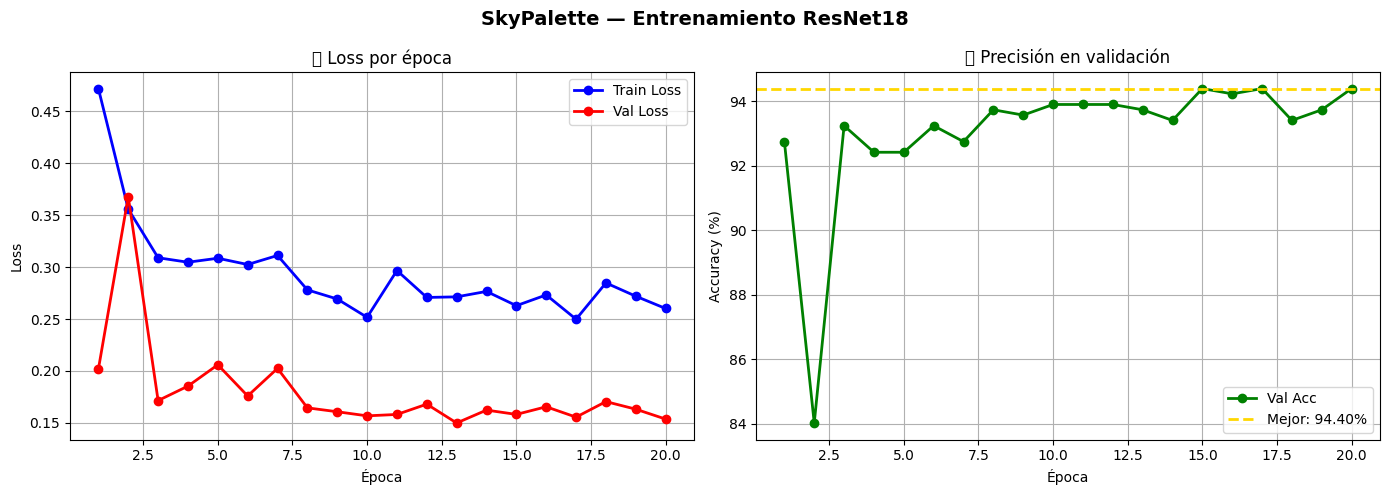

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, history["train_loss"], 'b-o', linewidth=2, label="Train Loss")
ax1.plot(epochs, history["val_loss"],   'r-o', linewidth=2, label="Val Loss")
ax1.set_title("📉 Loss por época")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(epochs, [v*100 for v in history["val_acc"]], 'g-o', linewidth=2, label="Val Acc")
ax2.axhline(y=best_val_acc*100, color='gold', linestyle='--', linewidth=2, label=f'Mejor: {best_val_acc:.2%}')
ax2.set_title("📈 Precisión en validación")
ax2.set_xlabel("Época")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True)

plt.suptitle("SkyPalette — Entrenamiento ResNet18", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

AI Score

In [ ]:
def predict_ai_score(image: Image.Image) -> float:
    """
    Recibe una imagen PIL y devuelve la probabilidad (0-100) de que
    el atardecer sea espectacular según el modelo entrenado.

    Pasos:
        1. Convierte a RGB y aplica las transformaciones
        2. Añade dimensión de batch (unsqueeze)
        3. Pasa por el modelo en modo inferencia (sin gradientes)
        4. Aplica softmax para obtener probabilidades
        5. Devuelve la probabilidad de la clase 'spectacular' × 100
    """
    tensor = TRANSFORMS(image.convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(MODEL(tensor), dim=1)
    return round(probs[0][SPECTACULAR_IDX].item() * 100, 1)

Analizador de colores

In [ ]:
"""
color_analyzer.py
-----------------
Analiza la paleta de colores de una imagen de atardecer y devuelve
una puntuación basada en criterios específicos para este tipo de fotografía.

La clave del análisis es evaluar solo la FRANJA DEL HORIZONTE (25%-70% de altura),
evitando que el cielo gris superior o el suelo inferior penalicen injustamente.
"""

import cv2
import numpy as np
from PIL import Image


def analyze_colors(image: Image.Image) -> dict:
    """
    Analiza la paleta de colores de la franja del horizonte de la imagen.

    Criterios evaluados:
        1. sat_score      — Saturación media de los píxeles cálidos, ponderada por brillo
        2. warm_score     — Cobertura de colores cálidos (naranja/rojo/dorado) × brillo
        3. diversity_score— Variedad de rangos cromáticos presentes
        4. horizon_score  — Intensidad visual (píxeles saturados Y brillantes)
        5. contrast_bonus — +10 pts si conviven tonos cálidos Y fríos (azul + naranja)

    El brightness_factor penaliza atardeceres oscuros (nubes tapando el sol):
        - Atardecer brillante (V~200): factor ~0.73
        - Atardecer oscuro (V~140):    factor ~0.43
    """
    img_rgb = np.array(image.convert("RGB"))
    h, w = img_rgb.shape[:2]

    if h < 10 or w < 10:
        return {"sat_score": 0.0, "warm_score": 0.0, "diversity_score": 0.0, "horizon_score": 0.0, "contrast_bonus": 0.0}

    # Convertir a espacio de color HSV — mucho más útil que RGB para detectar colores
    # H: tono 0-179 (rojo=0, verde=60, azul=120)
    # S: saturación 0-255 (0=gris, 255=color puro)
    # V: brillo 0-255 (0=negro, 255=máximo brillo)
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    H = img_hsv[:, :, 0]
    S = img_hsv[:, :, 1]
    V = img_hsv[:, :, 2]

    # ── Zona del horizonte (25%-70% de altura) ───────────────────────────────
    # Ignoramos el cielo gris superior y el suelo inferior que bajarían el score
    hz1 = int(h * 0.25)
    hz2 = int(h * 0.70)
    H_hz = H[hz1:hz2, :]
    S_hz = S[hz1:hz2, :]
    V_hz = V[hz1:hz2, :]
    total_hz = H_hz.size

    # ── Máscara de colores cálidos en el horizonte ───────────────────────────
    # Naranja/rojo (H 0-25), amarillo/dorado (H 25-40),
    # rosa/magenta (H 125-155), rojo oscuro (H 155-179)
    # Requiere S>50 (no grises) y V>50 (no negros)
    wm_hz = (
        ((H_hz >= 0)   & (H_hz <= 25))  |
        ((H_hz >= 155) & (H_hz <= 179)) |
        ((H_hz >= 25)  & (H_hz <= 40))  |
        ((H_hz >= 125) & (H_hz <= 155))
    ) & (S_hz > 50) & (V_hz > 50)

    warm_vals     = V_hz[wm_hz]
    warm_ratio_hz = np.sum(wm_hz) / total_hz

    # Factor de brillo elevado al exponente 1.5 para ampliar la diferencia
    # entre atardeceres brillantes y oscuros
    mean_V_warm       = float(np.mean(warm_vals)) if len(warm_vals) > 0 else 0
    brightness_factor = (mean_V_warm / 255) ** 1.5

    # ── Criterio 1 — Saturación ponderada por brillo ─────────────────────────
    warm_pixels_sat = S_hz[wm_hz]
    sat_raw   = float(np.mean(warm_pixels_sat) / 255 * 100) if len(warm_pixels_sat) > 0 else 0.0
    sat_score = round(sat_raw * brightness_factor, 1)

    # ── Criterio 2 — Cobertura cálida × brillo ───────────────────────────────
    # Un parche naranja oscuro (detrás de nubes) no puntúa alto
    # porque brightness_factor lo penaliza
    warm_score = round(min(warm_ratio_hz * 100 * 4.0 * brightness_factor, 100.0), 1)

    # ── Criterio 3 — Diversidad cromática en el horizonte ────────────────────
    # Cuenta cuántos de los 6 rangos de color están presentes con >0.8% de píxeles
    color_ranges = [
        ((H_hz >= 0)   & (H_hz <= 15))  & (S_hz > 50),   # rojo
        ((H_hz >= 15)  & (H_hz <= 30))  & (S_hz > 50),   # naranja
        ((H_hz >= 30)  & (H_hz <= 45))  & (S_hz > 50),   # amarillo
        ((H_hz >= 100) & (H_hz <= 130)) & (S_hz > 35),   # azul
        ((H_hz >= 125) & (H_hz <= 155)) & (S_hz > 50),   # rosa/magenta
        ((H_hz >= 155) & (H_hz <= 179)) & (S_hz > 50),   # rojo oscuro
    ]
    ranges_present  = sum(1 for r in color_ranges if np.sum(r) / total_hz > 0.008)
    diversity_score = round((ranges_present / len(color_ranges)) * 100, 1)

    # ── Criterio 4 — Intensidad visual del horizonte ─────────────────────────
    # Solo cuenta píxeles con S>80 Y V>120: saturados Y brillantes a la vez
    vivid_hz      = (S_hz > 80) & (V_hz > 120)
    horizon_score = round(min(float(np.sum(vivid_hz) / total_hz) * 100 * 3.5, 100.0), 1)

    # ── Bonus contraste cálido-frío ───────────────────────────────────────────
    # Naranja + azul conviviendo = atardecer fotogénico
    # Solo aplica si el atardecer es suficientemente brillante
    cold_mask_hz   = ((H_hz >= 85) & (H_hz <= 130)) & (S_hz > 35)
    has_warm       = warm_ratio_hz > 0.05
    has_cold       = np.sum(cold_mask_hz) / total_hz > 0.05
    contrast_bonus = 10.0 if (has_warm and has_cold and brightness_factor > 0.55) else 0.0

    return {
        "sat_score":       sat_score,
        "warm_score":      warm_score,
        "diversity_score": diversity_score,
        "horizon_score":   horizon_score,
        "contrast_bonus":  contrast_bonus,
    }


def compute_color_score(colors: dict) -> float:
    """
    Combina los criterios en un score final de color (0-100).
    Pesos ajustados por el usuario para priorizar la cobertura cálida.
    """
    raw = (
        colors["sat_score"]            * 0.1  +   # 10% saturación
        colors["warm_score"]           * 0.4  +   # 40% cobertura cálida (criterio principal)
        colors["diversity_score"]      * 0.25 +   # 25% variedad cromática
        colors["horizon_score"]        * 0.25 +   # 25% intensidad visual
        colors.get("contrast_bonus", 0)            # +10 bonus fijo si hay contraste
    )
    return round(min(raw, 100.0), 1)


def get_label(score: float) -> str:
    """Convierte una puntuación numérica en etiqueta descriptiva con emoji."""
    if   score >= 85: return "🌅 Espectacular"
    elif score >= 70: return "😍 Muy bueno"
    elif score >= 50: return "🙂 Aceptable"
    elif score >= 30: return "😐 Mediocre"
    else:             return "😶 Aburrido"


✅ Analizador de colores listo


Score híbrido IA + Color

In [ ]:
def hybrid_score(image: Image.Image) -> dict:
    """
    Combina la puntuación de la IA con el análisis de colores
    para dar una puntuación final más precisa entre atardeceres.

    Usa las mismas funciones que el backend:
      - predict_ai_score  →  score IA (0-100)
      - analyze_colors    →  desglose de color
      - compute_color_score → score de color (0-100)
    """

    # ── Score IA (0-100) ──────────────────────────────────────────────────
    ai_score = predict_ai_score(image)

    # ── Score Color (0-100) ───────────────────────────────────────────────
    colors      = analyze_colors(image)
    color_score = compute_color_score(colors)

    # ── Score Final ───────────────────────────────────────────────────────
    # Peso IA: 0.55  |  Peso Color: 0.45
    final_score = round((ai_score * 0.55) + (color_score * 0.45), 1)

    label = get_label(final_score)

    return {
        "final_score":  final_score,
        "label":        label,
        "ai_score":     ai_score,
        "color_score":  round(color_score, 1),
        "color_detail": colors
    }

print("✅ Función hybrid_score lista")

✅ Función hybrid_score lista


Probarlo con una foto

📸 Sube una foto de un atardecer...


Saving 61fab1c309d6f.jpeg to 61fab1c309d6f (1).jpeg


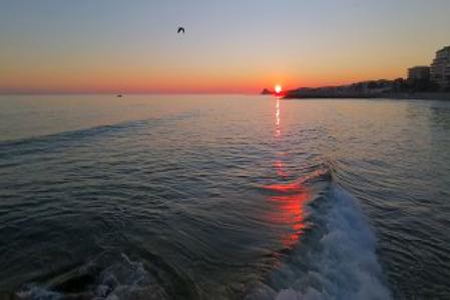


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🏆 Score Final  : 52.8 / 100
  Veredicto       : 🙂 Aceptable
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🤖 Score IA     : 55.6
  🎨 Score Color  : 48.5
  ─────────────────────────────────────
    Saturación    : 39.3
    Colores cálidos : 49.2
    Diversidad    : 66.7
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [ ]:
from google.colab import files
from IPython.display import display

print("📸 Sube una foto de un atardecer...")
uploaded = files.upload()
path = list(uploaded.keys())[0]

img = Image.open(path)
display(img.resize((450, 300)))

r = hybrid_score(img)

print()
print("━" * 40)
print(f"  🏆 Score Final  : {r['final_score']} / 100")
print(f"  Veredicto       : {r['label']}")
print("━" * 40)
print(f"  🤖 Score IA     : {r['ai_score']}")
print(f"  🎨 Score Color  : {r['color_score']}")
print("  ─────────────────────────────────────")
print(f"    Saturación      : {r['color_detail']['sat_score']}")
print(f"    Calidez         : {r['color_detail']['warm_score']}")
print(f"    Diversidad      : {r['color_detail']['diversity_score']}")
print(f"    Horizonte       : {r['color_detail']['horizon_score']}")
print(f"    Bonus contraste : {r['color_detail']['contrast_bonus']}")
print("━" * 40)